In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("train:", train.shape)
print("test :", test.shape)

train.head()

train: (42000, 785)
test : (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


正解: 1


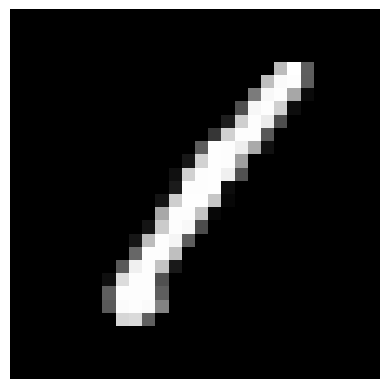

In [4]:

print("正解:", train.iloc[0, 0])
# 784個のpixelを28×28に戻す
image = train.iloc[0, 1:].values.reshape(28, 28)
# 画像として表示
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
X = train.drop("label", axis=1)
y = train["label"]
X_test = test.copy()

In [6]:
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (42000, 784)
y: (42000,)
X_test: (28000, 784)


In [7]:
# 欠損値の確認
print("Xの欠損値:", X.isnull().sum().sum())
print("yの欠損値:", y.isnull().sum())

# 重複データの確認
print("重複行:", train.duplicated().sum())

# pixel値の範囲
print("pixel最小値:", X.min().min())
print("pixel最大値:", X.max().max())

# 各数字のデータ数
print("\nラベルごとのデータ数")
print(y.value_counts().sort_index())

Xの欠損値: 0
yの欠損値: 0
重複行: 0
pixel最小値: 0
pixel最大値: 255

ラベルごとのデータ数
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [8]:
X = X / 255.0
X_test = X_test / 255.0
print("最小値:", X.min().min())
print("最大値:", X.max().max())

最小値: 0.0
最大値: 1.0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (33600, 784)
X_val: (8400, 784)
y_train: (33600,)
y_val: (8400,)


In [10]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
from sklearn.metrics import accuracy_score

y_pred = model_lr.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9129761904761905


In [12]:
# 学習データに対する予測
y_train_pred = model_lr.predict(X_train)

# 学習データでのAccuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy  :", train_accuracy)
print("Validation Accuracy:", accuracy)

Training Accuracy  : 0.9459821428571429
Validation Accuracy: 0.9129761904761905


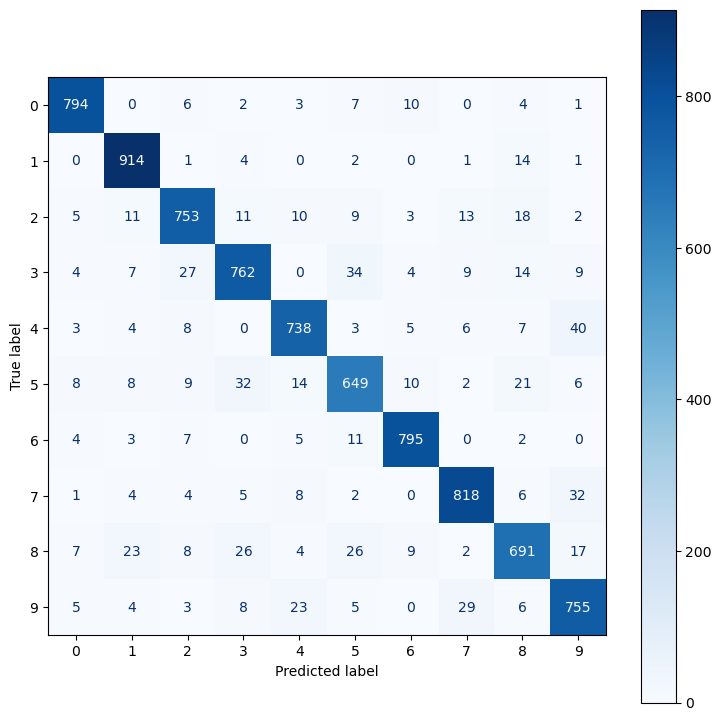

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 混同行列を計算
cm = confusion_matrix(y_val, y_pred)

# 可視化
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.show()

In [14]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

model_mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,128
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,42


In [15]:
from sklearn.metrics import accuracy_score

# 学習データ
y_train_pred_mlp = model_mlp.predict(X_train)

# 検証データ
y_val_pred_mlp = model_mlp.predict(X_val)

train_acc_mlp = accuracy_score(y_train, y_train_pred_mlp)
val_acc_mlp = accuracy_score(y_val, y_val_pred_mlp)

print("MLP Training Accuracy  :", train_acc_mlp)
print("MLP Validation Accuracy:", val_acc_mlp)
print("Generalization Gap     :", train_acc_mlp - val_acc_mlp)
print("Epochs                 :", model_mlp.n_iter_)

MLP Training Accuracy  : 0.9975
MLP Validation Accuracy: 0.973452380952381
Generalization Gap     : 0.024047619047619095
Epochs                 : 42


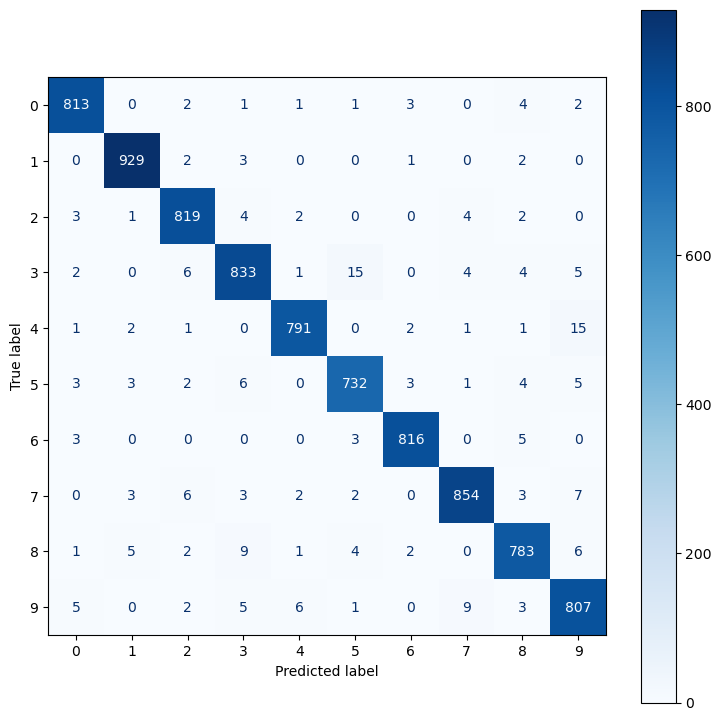

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# MLPの混同行列
cm_mlp = confusion_matrix(y_val, y_val_pred_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=range(10)
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.show()

In [17]:
import numpy as np

X_train_cnn = X_train.to_numpy().reshape(-1, 28, 28, 1)
X_val_cnn = X_val.to_numpy().reshape(-1, 28, 28, 1)

print("Training:", X_train_cnn.shape)
print("Validation:", X_val_cnn.shape)

Training: (33600, 28, 28, 1)
Validation: (8400, 28, 28, 1)


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.keras.utils.set_random_seed(42)

model_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 56s 200ms/step - accuracy: 0.8996 - loss: 0.3287 - val_accuracy: 0.9724 - val_loss: 0.0867
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 49s 186ms/step - accuracy: 0.9739 - loss: 0.0866 - val_accuracy: 0.9801 - val_loss: 0.0676
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.9814 - loss: 0.0595 - val_accuracy: 0.9835 - val_loss: 0.0531
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.9839 - loss: 0.0497 - val_accuracy: 0.9851 - val_loss: 0.0499
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 44s 169ms/step - accuracy: 0.9879 - loss: 0.0374 - val_accuracy: 0.9868 - val_loss: 0.0467
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 6528s 25s/step - accuracy: 0.9899 - loss: 0.0309 - val_accuracy: 0.9875 - val_loss: 0.0437
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 87s 202ms/step - accuracy: 0.9912 - loss: 0.0286 - val_accuracy: 0.9870 - val_loss: 0.0439
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 45s 170ms/step - accuracy: 0.9922 - loss: 0

In [20]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.05)
])

In [21]:
model_cnn_v2 = tf.keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_cnn_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_cnn_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_v2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_v2 = model_cnn_v2.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop_v2],
    verbose=1
)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 67s 220ms/step - accuracy: 0.8245 - loss: 0.5565 - val_accuracy: 0.9675 - val_loss: 0.1038
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 42s 159ms/step - accuracy: 0.9392 - loss: 0.1967 - val_accuracy: 0.9781 - val_loss: 0.0674
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 39s 148ms/step - accuracy: 0.9548 - loss: 0.1442 - val_accuracy: 0.9810 - val_loss: 0.0581
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.9625 - loss: 0.1235 - val_accuracy: 0.9844 - val_loss: 0.0492
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 41s 155ms/step - accuracy: 0.9686 - loss: 0.1055 - val_accuracy: 0.9893 - val_loss: 0.0386
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.9700 - loss: 0.0967 - val_accuracy: 0.9860 - val_loss: 0.0438
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 40s 153ms/step - accuracy: 0.9739 - loss: 0.0859 - val_accuracy: 0.9855 - val_loss: 0.0449
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.9751 - loss: 0

In [ ]:
train_loss_v2, train_acc_v2 = model_cnn_v2.evaluate(
    X_train_cnn, y_train, verbose=0
)

val_loss_v2, val_acc_v2 = model_cnn_v2.evaluate(
    X_val_cnn, y_val, verbose=0
)

print(f"Training Accuracy  : {train_acc_v2:.4f}")
print(f"Validation Accuracy: {val_acc_v2:.4f}")
print(f"Generalization Gap : {train_acc_v2 - val_acc_v2:.4f}")